In [1]:
import shap

print(shap.__version__)

0.40.0


### 1. Global Explainability
What Features drive the model's predictions overall?

In [2]:
# Load models
import joblib

final_model = joblib.load("../models/xgboost_credit_score.pkl")

final_preprocessor = joblib.load("../models/preprocessor.pkl")

pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


In [3]:
print(type(final_model))
print(type(final_preprocessor))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [4]:
X_test_processed = joblib.load("../data/processed/X_test_processed.pkl")

y_test = joblib.load("../data/processed/y_test.pkl")

test_customer_ids = joblib.load("../data/processed/test_customer_ids.pkl"
)

feature_names = joblib.load("../data/processed/feature_names.pkl")

In [5]:
print("X_test:", X_test_processed.shape)
print("y_test:", y_test.shape)
print("Customer IDs:", test_customer_ids.shape)
print("Features:", len(feature_names))

X_test: (15000, 61)
y_test: (15000,)
Customer IDs: (15000,)
Features: 61


In [6]:
# create SHAP explainer
explainer = shap.TreeExplainer(final_model)

In [7]:
# Create a representative SHAP sample
X_test_sample = X_test_processed[:1000]
y_test_sample = y_test.iloc[:1000]

print("X sample shape:", X_test_sample.shape)
print("y sample shape:", y_test_sample.shape)

X sample shape: (1000, 61)
y sample shape: (1000,)


In [8]:
# Calculate SHAp values
shap_values = explainer.shap_values(X_test_sample)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


In [9]:
print(type(shap_values))
print(len(shap_values))

<class 'list'>
3


In [10]:
for i, class_name in enumerate(final_model.classes_):
    print(class_name, shap_values[i].shape)

Good (1000, 61)
Poor (1000, 61)
Standard (1000, 61)


In [11]:
print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 61
['numeric__Age' 'numeric__Annual_Income' 'numeric__Monthly_Inhand_Salary'
 'numeric__Num_Bank_Accounts' 'numeric__Num_Credit_Card'
 'numeric__Interest_Rate' 'numeric__Num_of_Loan'
 'numeric__Delay_from_due_date' 'numeric__Num_of_Delayed_Payment'
 'numeric__Changed_Credit_Limit' 'numeric__Num_Credit_Inquiries'
 'numeric__Outstanding_Debt' 'numeric__Credit_Utilization_Ratio'
 'numeric__Total_EMI_per_month' 'numeric__Amount_invested_monthly'
 'numeric__Monthly_Balance' 'numeric__Credit_History_Months'
 'numeric__Num_Loan_Types' 'numeric__Has_auto_loan'
 'numeric__Has_credit_builder_loan' 'numeric__Has_personal_loan'
 'numeric__Has_home_equity_loan' 'numeric__Has_mortgage_loan'
 'numeric__Has_student_loan' 'numeric__Has_debt_consolidation_loan'
 'numeric__Has_payday_loan' 'categorical__Month_April'
 'categorical__Month_August' 'categorical__Month_February'
 'categorical__Month_January' 'categorical__Month_July'
 'categorical__Month_June' 'categorical__Month_Marc

In [12]:
import numpy as np
import pandas as pd

In [13]:
# first SHAP importance table
poor_shap_importance = pd.DataFrame({
    "Features": feature_names,
    "Mean_Abs_SHAP": np.abs(shap_values[1].mean(axis=0))
})

poor_shap_importance = poor_shap_importance.sort_values("Mean_Abs_SHAP", ascending=False)

poor_shap_importance.head(20)

,Features,Mean_Abs_SHAP
11,numeric__Outstanding_Debt,0.108010
16,numeric__Credit_History_Months,0.064158
10,numeric__Num_Credit_Inquiries,0.054505
7,numeric__Delay_from_due_date,0.045984
49,categorical__Credit_Mix_Bad,0.025351
50,categorical__Credit_Mix_Good,0.015010
1,numeric__Annual_Income,0.012934
51,categorical__Credit_Mix_Standard,0.012721
13,numeric__Total_EMI_per_month,0.009985
54,categorical__Payment_of_Min_Amount_Yes,0.009812


In [14]:
import matplotlib.pyplot as plt

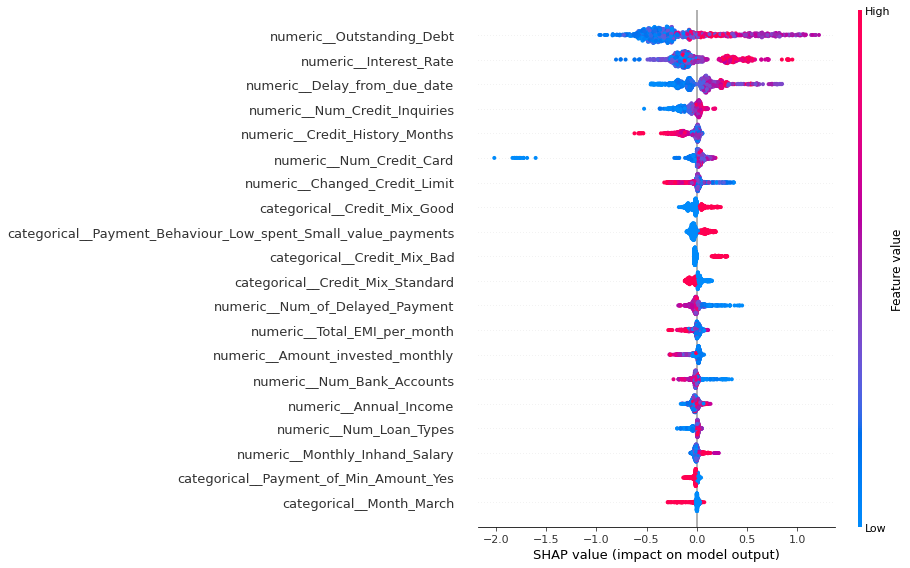

<Figure size 432x288 with 0 Axes>

In [15]:
# create the poor SHAP summary plot
shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names)
plt.savefig("../images/poor_shapplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

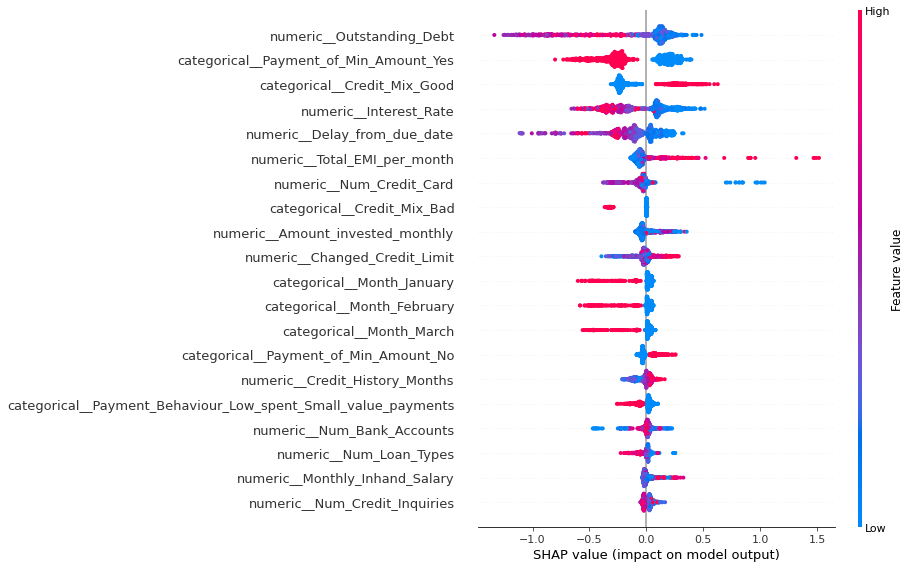

<Figure size 432x288 with 0 Axes>

In [16]:
# create the good SHAP summary plot
shap.summary_plot(shap_values[0], X_test_sample, feature_names=feature_names)
plt.savefig("../images/good_shapplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

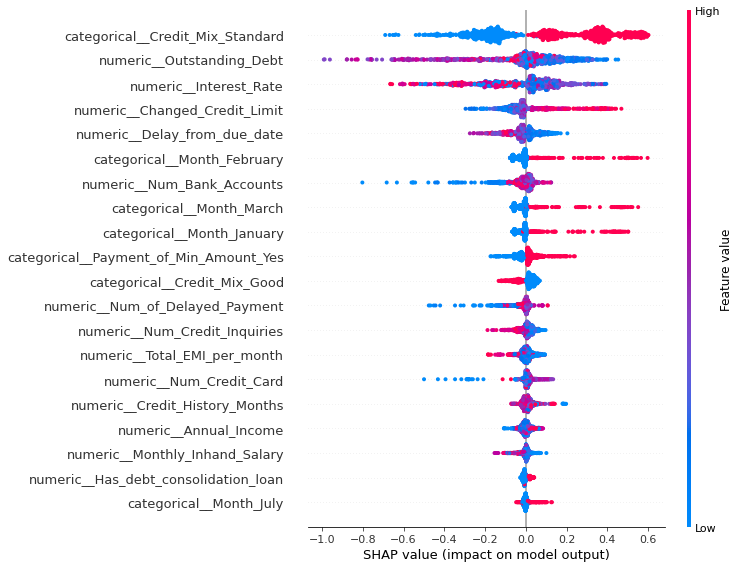

<Figure size 432x288 with 0 Axes>

In [17]:
# create the standard SHAP summary plot
shap.summary_plot(shap_values[2], X_test_sample, feature_names=feature_names)
plt.savefig("../images/standard_shapplot.png")

In [18]:
# Create importance table for all classes
shap_importance = pd.DataFrame({
    "Features": feature_names,
    "Good": np.abs(shap_values[0]).mean(axis=0),
    "Poor": np.abs(shap_values[1]).mean(axis=0),
    "Standard": np.abs(shap_values[2]).mean(axis=0),
})

shap_importance["Overall"] = shap_importance[["Good", "Poor", "Standard"]].mean(axis=1)

shap_importance = shap_importance.sort_values("Overall", ascending=False)

shap_importance.head(20)

,Features,Good,Poor,Standard,Overall
11,numeric__Outstanding_Debt,0.305311,0.394250,0.154586,0.284716
5,numeric__Interest_Rate,0.222983,0.211723,0.142459,0.192388
7,numeric__Delay_from_due_date,0.173388,0.174997,0.048626,0.132337
50,categorical__Credit_Mix_Good,0.237069,0.053336,0.033594,0.108000
54,categorical__Payment_of_Min_Amount_Yes,0.268097,0.018581,0.036488,0.107722
51,categorical__Credit_Mix_Standard,0.005309,0.043818,0.271427,0.106852
9,numeric__Changed_Credit_Limit,0.055628,0.056781,0.082885,0.065098
4,numeric__Num_Credit_Card,0.075322,0.071385,0.020545,0.055751
13,numeric__Total_EMI_per_month,0.096009,0.033647,0.022076,0.050577
16,numeric__Credit_History_Months,0.047316,0.076330,0.018491,0.047379


In [19]:
import sys

sys.path.append("../")

from src.explainability import CreditScoreExplainer

In [20]:
print(CreditScoreExplainer)

<class 'src.explainability.CreditScoreExplainer'>


In [21]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "Credit_History_Months",
    "Num_Loan_Types",
    "Has_auto_loan",
    "Has_credit_builder_loan",
    "Has_personal_loan",
    "Has_home_equity_loan",
    "Has_mortgage_loan",
    "Has_student_loan",
    "Has_debt_consolidation_loan",
    "Has_payday_loan"
]

categorical_features = [
    "Month",
    "Occupation",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

In [22]:
# Instantiate the explainer
explainer_model = CreditScoreExplainer(
    model=final_model,
    feature_names=feature_names,
    numeric_features=numeric_features,
    categorical_features=categorical_features
)

In [23]:
import pandas as pd

test_df = joblib.load("../data/processed/test_df.pkl")

print("Test shape:", test_df.shape)
print("Unique customers:", test_df["Customer_ID"].nunique())

Test shape: (15000, 36)
Unique customers: 1875


In [28]:
position = 600

X_single = X_test_processed[position:position + 1]

raw_row = test_df.iloc[[position]]

In [29]:
print("Customer:", raw_row["Customer_ID"])
print("Actual:", raw_row["Credit_Score"])

Customer: 4392    CUS_0xbf55
Name: Customer_ID, dtype: object
Actual: 4392    Poor
Name: Credit_Score, dtype: object


In [31]:
result = explainer_model.explain_observation(
    X_processed=X_single,
    original_row=raw_row,
    observation_index=0,
    top_n=15
)

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


In [32]:
print("Prediction:", result["prediction"])
print("Confidence:", round(result["confidence"], 4))

Prediction: Poor
Confidence: 0.8795


In [33]:
result["probabilities"]

{'Good': 0.012308368, 'Poor': 0.8794717, 'Standard': 0.10821995}

In [34]:
result["explanation"]

,Feature,Category,Value,SHAP,Abs_SHAP,Direction
7,Delay_from_due_date,None,57,0.546351,0.546351,Toward Poor
5,Interest_Rate,None,25,0.515025,0.515025,Toward Poor
11,Outstanding_Debt,None,1397.24,0.384478,0.384478,Toward Poor
10,Num_Credit_Inquiries,None,11.0,0.089323,0.089323,Toward Poor
26,Month,January,January,0.068769,0.068769,Toward Poor
9,Changed_Credit_Limit,None,7.98,0.048566,0.048566,Toward Poor
16,Credit_History_Months,None,173.0,0.042775,0.042775,Toward Poor
4,Num_Credit_Card,None,9,0.039976,0.039976,Toward Poor
30,Payment_Behaviour,High_spent_Medium_value_payments,High_spent_Medium_value_payments,-0.039254,0.039254,Away from Poor
1,Annual_Income,None,16893.44,-0.035258,0.035258,Away from Poor
